# Parametric PINN Training (02 layout)

This notebook reuses the structure of **02_pinn_train.ipynb** but implements the
parametric/`ParamBC` logic from the dedicated parametric notebook.  

## Setup

In [1]:
import sys
from pathlib import Path
from dataclasses import dataclass
import json
import time
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Could not find project root containing /src")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.utils import set_seed, get_device
from src.data import load_manifest_rows, load_case_manifest_row, ParamPINNBatch
from src.pinn import MLP, LossWeights

set_seed(42)
device = get_device()
print(f"Project root: {ROOT}")
print(f"Device: {device}")

SENSOR_XI = 0.5
MU_TIME_SAMPLES = 25
MU_USE_SENSOR_XI = True

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
OUTDIR = ROOT / "outputs" / "parametric" / RUN_ID
OUTDIR.mkdir(parents=True, exist_ok=True)
print(f"RUN_ID: {RUN_ID}")
print(f"OUTDIR: {OUTDIR}")

Project root: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN
Device: cpu
RUN_ID: 20260310_111046
OUTDIR: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\20260310_111046


## Data Loading and Case Split

In [2]:
manifest = ROOT / "data" / "manifest.csv"
rows = load_manifest_rows(manifest)
if len(rows) < 2:
    raise RuntimeError("Need at least two cases for train/held-out split.")

# deterministic split; keep final 20% as held-out
rows_sorted = sorted(rows, key=lambda r: r["case_id"])
n_val_cases = max(1, int(round(0.2 * len(rows_sorted))))
val_rows = rows_sorted[-n_val_cases:]
train_rows = rows_sorted[:-n_val_cases]

if len(train_rows) == 0:
    raise RuntimeError("Split produced no training cases.")

print("Train cases:", [r["case_id"] for r in train_rows])
print("Held-out cases:", [r["case_id"] for r in val_rows])

Train cases: ['const_10000', 'const_15000', 'const_5000', 'offset_sine_1', 'sine_A10000_T100', 'sine_A10000_T50']
Held-out cases: ['sine_A5000_T100', 'sine_A5000_T50']


## Data Preprocessing and Parametric Batch

In [3]:
def compute_mu_stats(cases):
    eps = 1e-8
    all_mu = np.array([c["mu_raw"] for c in cases])
    mu_min = all_mu.min(axis=0)
    mu_max = all_mu.max(axis=0)
    return {
        "mu_min": mu_min,
        "mu_max": mu_max,
        "eps": eps,
    }


def normalise_mu(mu_raw, mu_stats):
    eps = mu_stats["eps"]
    mu_min = mu_stats["mu_min"]
    mu_max = mu_stats["mu_max"]
    return 2.0 * (mu_raw - mu_min) / (mu_max - mu_min + eps) - 1.0


def _load_case_with_mu(row: dict) -> dict:
    c = load_case_manifest_row(row, root=ROOT)
    
    # Extract mu from sensor time series
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]
    
    xi_idx = np.argmin(np.abs(xi - SENSOR_XI))
    tau_max = tau.max()
    tau_samples = np.linspace(0, tau_max, MU_TIME_SAMPLES)
    theta_series = np.interp(tau_samples, tau, theta[xi_idx, :])
    
    mu_raw = theta_series.astype(np.float32)
    if MU_USE_SENSOR_XI:
        mu_raw = np.concatenate([[SENSOR_XI], mu_raw])
    
    c["mu_raw"] = mu_raw
    c["mu"] = mu_raw  # Will be normalized later
    
    L = float(c["physical"]["L"])
    alpha = float(c["physical"]["alpha"])
    k = float(c["physical"]["k"])
    dT_ref = float(c["physical"]["dT_ref"])
    c["time_scale"] = np.float32((L**2) / alpha)         # t = tau * time_scale
    c["flux_scale"] = np.float32(k * dT_ref / L)          # theta_x = -q / flux_scale
    return c

train_cases = [_load_case_with_mu(r) for r in train_rows]
val_cases = [_load_case_with_mu(r) for r in val_rows]

mu_stats = compute_mu_stats(train_cases)
for c in (train_cases + val_cases):
    c["mu"] = normalise_mu(c["mu_raw"], mu_stats)

print(f"Loaded {len(train_cases)} train cases and {len(val_cases)} held-out cases.")
print("mu_stats min:", mu_stats["mu_min"][:5], "...")  # Show first 5
print("mu_stats max:", mu_stats["mu_max"][:5], "...")

# Example mu
if train_cases:
    print("Example mu:", train_cases[0]["mu"][:5], "...")

all_mu = np.stack([c["mu"] for c in (train_cases + val_cases)], axis=0)
print("mu_vector mins:", all_mu.min(axis=0)[:5], "...")
print("mu_vector maxs:", all_mu.max(axis=0)[:5], "...")

Loaded 6 train cases and 2 held-out cases.
mu_stats min: [ 0.5         0.         -0.0195793  -0.07050018 -0.12354179] ...
mu_stats max: [ 0.5         0.         -0.00087723 -0.00803719 -0.02365795] ...
Example mu: [-1.         -1.         -0.99977531 -0.99993273 -1.        ] ...
mu_vector mins: [-1. -1. -1. -1. -1.] ...
mu_vector maxs: [-1.         -1.          1.00041711  0.99999968  0.9999998 ] ...


In [8]:
# Check sensor traces differ
for c in train_cases[:3]:  # check first 3
    print(f"Case {c['case_id']}: mu_raw[:5] = {c['mu_raw'][:5]}")
print("...")

Case const_10000: mu_raw[:5] = [ 0.5         0.         -0.0195772  -0.07049808 -0.12354179]
Case const_15000: mu_raw[:5] = [ 0.5         0.         -0.0195786  -0.07049948 -0.12354074]
Case const_5000: mu_raw[:5] = [ 0.5         0.         -0.0195793  -0.07050018 -0.12353864]
...


## Create Batch

In [4]:
# collocation points (same for train/val)
rng = np.random.default_rng(42)
n_r = 50000

# determine nondimensional tau range across training cases (use for sampling)
tau_max = max(c["nondim"]["tau"].max() for c in train_cases)
xi_r = rng.uniform(0.0, 1.0, size=(n_r, 1)).astype(np.float32)
tau_r = rng.uniform(0.0, float(tau_max), size=(n_r, 1)).astype(np.float32)

# assemble training batch using param cases
# (concatenate nondimensional data from all train cases)
xi_data_train = []
tau_data_train = []
theta_data_train = []
mu_data_train = []

for c in train_cases:
    # use nondimensional arrays provided by load_case_manifest_row
    xi = c["nondim"]["xi"]            # (Nx,)
    tau = c["nondim"]["tau"]          # (Nt,)
    theta = c["nondim"]["theta"]      # (Nx, Nt)

    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    xi_data_train.append(xi_grid.reshape(-1, 1))
    tau_data_train.append(tau_grid.reshape(-1, 1))
    theta_data_train.append(theta.reshape(-1, 1))
    mu_data_train.append(np.repeat(c["mu"].reshape(1, -1), xi_grid.size, axis=0))

xi_data_train = np.vstack(xi_data_train).astype(np.float32)
tau_data_train = np.vstack(tau_data_train).astype(np.float32)
theta_data_train = np.vstack(theta_data_train).astype(np.float32)
mu_data_train = np.vstack(mu_data_train).astype(np.float32)

# same for validation
xi_data_val = []
tau_data_val = []
theta_data_val = []
mu_data_val = []
for c in val_cases:
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]
    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    xi_data_val.append(xi_grid.reshape(-1, 1))
    tau_data_val.append(tau_grid.reshape(-1, 1))
    theta_data_val.append(theta.reshape(-1, 1))
    mu_data_val.append(np.repeat(c["mu"].reshape(1, -1), xi_grid.size, axis=0))

xi_data_val = np.vstack(xi_data_val).astype(np.float32)
tau_data_val = np.vstack(tau_data_val).astype(np.float32)
theta_data_val = np.vstack(theta_data_val).astype(np.float32)
mu_data_val = np.vstack(mu_data_val).astype(np.float32)

# create train/val batches
torch_zero = lambda *shape: torch.zeros(shape, dtype=torch.float32, device=device)

# sample mu for collocation points from training cases
rng_mu = np.random.default_rng(42)
mu_samples = np.array([c["mu"] for c in train_cases])
mu_r_train = rng_mu.choice(mu_samples, size=n_r, replace=True).astype(np.float32)
mu_r_val = rng_mu.choice(mu_samples, size=n_r//5, replace=True).astype(np.float32)

train_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r, dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_train, dtype=torch.float32, device=device),
    xi_ic=torch_zero(0, 1),
    tau_ic=torch_zero(0, 1),
    mu_ic=torch_zero(0, mu_data_train.shape[1]),
    theta_ic=torch_zero(0, 1),
    xi_bc=torch_zero(0, 1),
    tau_bc=torch_zero(0, 1),
    mu_bc=torch_zero(0, mu_data_train.shape[1]),
    bc_time_scale=torch_zero(0, 1),
    bc_flux_scale=torch_zero(0, 1),
    flux_bc=torch_zero(0, 1),
    xi_data=torch.tensor(xi_data_train, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_train, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_train, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_train, dtype=torch.float32, device=device),
)

val_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r[: n_r//5], dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r[: n_r//5], dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_val, dtype=torch.float32, device=device),
    xi_ic=torch_zero(0, 1),
    tau_ic=torch_zero(0, 1),
    mu_ic=torch_zero(0, mu_data_val.shape[1]),
    theta_ic=torch_zero(0, 1),
    xi_bc=torch_zero(0, 1),
    tau_bc=torch_zero(0, 1),
    mu_bc=torch_zero(0, mu_data_val.shape[1]),
    bc_time_scale=torch_zero(0, 1),
    bc_flux_scale=torch_zero(0, 1),
    flux_bc=torch_zero(0, 1),
    xi_data=torch.tensor(xi_data_val, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_val, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_val, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_val, dtype=torch.float32, device=device),
)

print("Data loaded and split successfully (parametric).")
print(f"mu_r shape: {train_batch.mu_r.shape}")

Data loaded and split successfully (parametric).
mu_r shape: torch.Size([50000, 26])


## Training

In [ ]:
# build model and weights
model = MLP(in_dim=2 + mu_data_train.shape[1], hidden=20, layers=2).to(device)
weights = LossWeights(w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0)

run_dir = Path(ROOT, "models", "checkpoints", "parametric")
run_dir.mkdir(parents=True, exist_ok=True)

best_path = None
import importlib
import src.pinn
importlib.reload(src.pinn)
import src.train
importlib.reload(src.train)
from src.train import train_adam, train_lbfgs

best_path = train_adam(
    model,
    train_batch,
    weights,
    lr=1e-3,
    run_dir=run_dir,
    val_batch=val_batch,
    print_every=1000,
    patience_evals=8,
    plateau_window=5,
    plateau_rel_tol=0.01,
    pde_guardrail_rel=0.10,
)

# polish with L-BFGS
best_lbfgs_path = train_lbfgs(
    model,
    train_batch,
    weights,
    max_iter=500,
    run_dir=run_dir,
)

print("Training completed.")

[Adam] step 1/20000 | total=3.3678e-01 (pde=3.06e-03, ic=0.00e+00, bc=0.00e+00, data=3.34e-01) | val_rmse=5.94e-01 | val_pde=2.55e-03 | grad=3.50e+00 | 0.6s


In [ ]:
# debug cell
import importlib
import src.pinn
import src.train
importlib.reload(src.pinn)
importlib.reload(src.train)
from src.train import compute_losses_eval

X_test = torch.cat([train_batch.xi_r[:10], train_batch.tau_r[:10], train_batch.mu_r[:10]], dim=1)
y_test = model(X_test)
print("Model output:", y_test)
print("Any nan:", torch.isnan(y_test).any())

try:
    loss, logs = compute_losses_eval(model, train_batch, weights)
    print("Initial loss:", loss.item())
    print("Logs:", logs)
except Exception as e:
    print("Error:", e)
    import traceback
    traceback.print_exc()

Model output: tensor([[-0.7551],
        [-0.2619],
        [-0.8148],
        [-0.2346],
        [-0.0741],
        [-0.5861],
        [-0.6286],
        [-0.1996],
        [-0.1073],
        [-0.0793]], grad_fn=<AddmmBackward0>)
Any nan: tensor(False)
Initial loss: 0.00415875343605876
Logs: {'total': 0.00415875343605876, 'pde': 0.0005846999119967222, 'ic': 0.0, 'bc': 0.0, 'data': 0.0035740535240620375, 'smooth': 0.0}


## Plot

In [ ]:
# (This section would produce quick comparison plots for a chosen held-out case.)
# Placeholder: reuse logic from original 02 notebook if desired.
print("Plotting not implemented for parametric version yet.")

Plotting not implemented for parametric version yet.


## Validation & Metrics

Loaded checkpoint: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\models\checkpoints\parametric\best.pt
Validation logs:
  total: 4.0047e-01
  pde: 5.6957e-04
  ic: 0.0000e+00
  bc: 0.0000e+00
  data: 3.9990e-01
  smooth: 0.0000e+00
Validation RMSE (data): 6.3238e-01


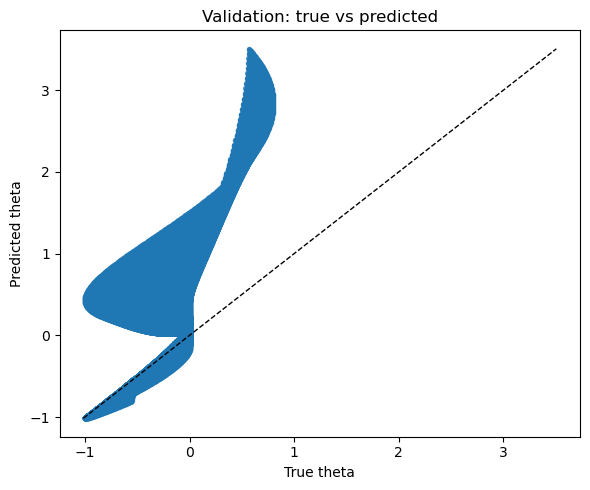

In [ ]:
# example validation on held-out data
import src.train as train_mod
importlib.reload(train_mod)
from src.train import compute_losses_eval

# load checkpoint
ckpt = best_path if best_path is not None else None
if ckpt is not None and ckpt.exists():
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state["state_dict"])
    model.to(device)
    print(f"Loaded checkpoint: {ckpt}")

val_loss, val_logs = compute_losses_eval(model, val_batch, weights)
print("Validation logs:")
for k, v in val_logs.items():
    print(f"  {k}: {v:.4e}")

if getattr(val_batch, "xi_data", None) is not None:
    model.eval()
    with torch.no_grad():
        X_val = torch.cat([val_batch.xi_data, val_batch.tau_data, val_batch.mu_data], dim=1).to(device)
        y_true = val_batch.theta_data.to(device)
        y_pred = model(X_val)
    mse = torch.mean((y_pred - y_true) ** 2).item()
    rmse = mse ** 0.5
    print(f"Validation RMSE (data): {rmse:.4e}")
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true.cpu().numpy(), y_pred.detach().cpu().numpy(), s=8, alpha=0.6)
    mn = min(y_true.min().item(), y_pred.min().item())
    mx = max(y_true.max().item(), y_pred.max().item())
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.xlabel("True theta")
    plt.ylabel("Predicted theta")
    plt.title("Validation: true vs predicted")
    plt.tight_layout()
    plt.show()
else:
    print("No interior validation data present in `val_batch` to plot.")

## Upload and update

In [ ]:
# replicate the architecture logger from 02 notebook
from utils.experiment_logger import append_result, compare_to_best, ensure_csv, load_best

results_csv = ROOT / "results" / "arch_search_parametric.csv"
ensure_csv(str(results_csv))
baseline_best = load_best(str(results_csv), metric="val_rmse_data")

# (same logging helper funcs as 02, omitted for brevity)
print("Logging logic should be copied here as needed.")

Logging logic should be copied here as needed.
